## Required Libraries

In [ ]:
!pip install langchain-groq
!pip install langchain-mcp-adapters # With the help of this we can use MCP capabilities with LangChain
!pip install mcp # This is FastMCP a package used to create MCP servers and tools efficiently
!pip install langgraph
!pip install python-dotenv

## Building MCP Server

A MCP server consists of majorly 3 components :

1. MCP Servers - Which provides acces to different tools and context, it can be a third party service or a third party API

2. MCP Clients - Requests MCP server for a specific tool or context and provide it to the agent or App

3. App - The agent or App we are building for example LangGraph Agent, Claude Desktop App, etc.

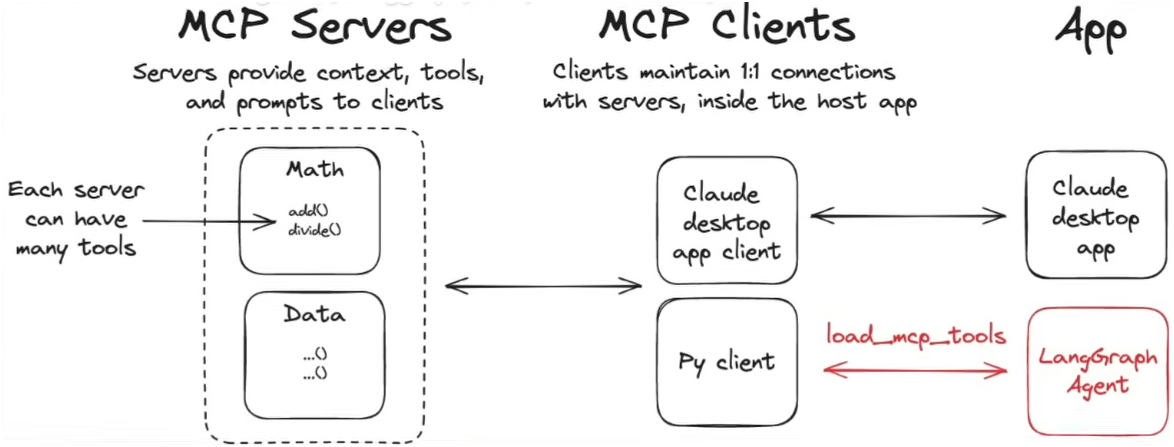

What we are building...

Basically we will build a ChatBot type of application which when get a input from user will make a call to our MCP Server and the server will provide the information or context according to the tools. So the things we will build in it are :

1. MCP Server
2. MCP Client


Whenever we talk about calling a MCP server there are different transport protocols like :

1. stdio
2. http

Here we will make one tool with stdio and one with http to understand both well

1. "transport = stdio"

Basically it tells the server to "Use standard input/output (stdin and stdout) to receive and respond to tool function calls".

Basically its good for testing if are working in local environment

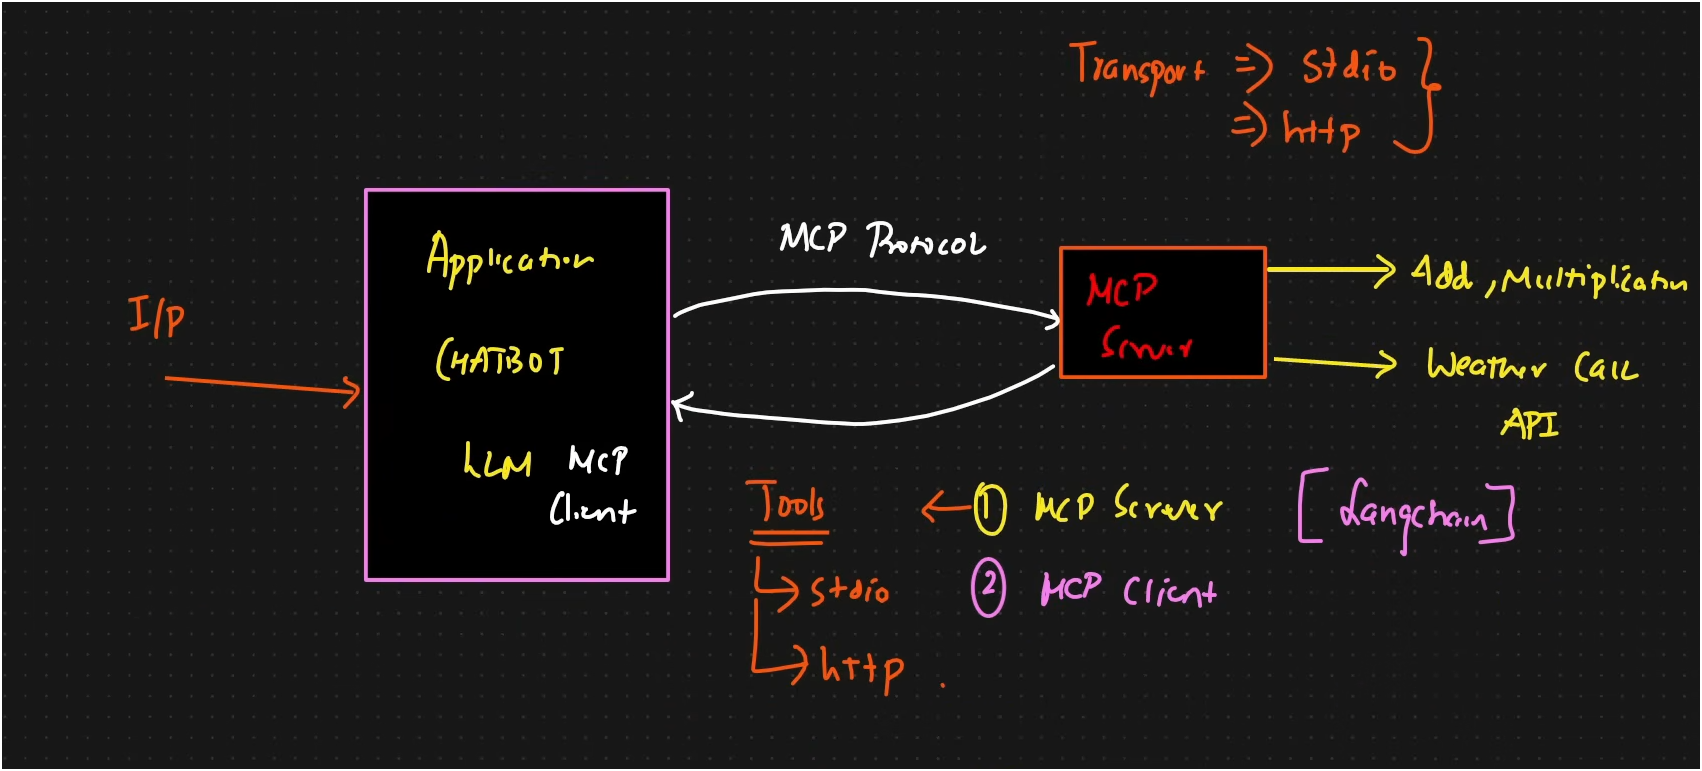

Let's craete some tools with FastMCP

Below code cell can be a file "mathserver.py". And here we are trying to create a MCP server which includes two tools add() and multiply() with the help of "stdio" transport

In [ ]:
from mcp.server.fastmcp import FastMCP

mcp = FastMCP("MathServer") # Object with a name of our server


@mcp.tool()
def add(a:int, b:int) -> int :
  """Add two numbers"""
  return a + b

@mcp.tool()
def multiply(a:int, b:int) -> int :
  """Multiply two numbers"""
  return a * b


if __name__ == "__main__":
  mcp.run() # Run this server using the "transport="stdio"

Below code cell can be named as "weather.py", This is another server with the use of "transport="http"

In [ ]:
from mcp.server.fastmcp import FastMCP

weather_mcp = FastMCP("WeatherServer")

@weather_mcp.tool()
async def get_weather(location:str) -> str:
  """Get weather for a particular location"""
  return f"Its always Raining in {location}" # Just for demo purposes, here code of getting weather information will come


if __name__ == "__main__":
  weather_mcp.run(transport="streamable-http")

When we run these two files then "MathServer.py" uses stdio as transport so we can't see anything on the terminal but when we run "Weather.py" it is using a "streamable-http" as a transport so it run in a form of API service at a specific URL.

Note : These both files will not run in the Collab Notebook because Collab also run a asyncio thread in background and if we run these files it may interrupt that main thread, but it will work in VS Code and other IDEs as described above

Now lets see how to integrate these two servers or how our client will utlise them.. The below code cell can be named as "client.py" and we will use LangChain adapters for this task

In [ ]:
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain.agents import create_agent
from langchain_groq import ChatGroq
import asyncio
from dotenv import load_dotenv
load_dotenv()

import os
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

model = ChatGroq(model="llama-3.3-70b-versatile", api_key=GROQ_API_KEY, streaming=True)

async def main():
    client = MultiServerMCPClient(
        {
            "MathServer" : { # Name of the server
                "command" : "python", # Can also use uvicorn here
                "args" : ["mathserver.py"], # Correct absolute path of the file in a list
                "transport" : "stdio" # Transport we are using for this particular server
            },
            "WeatherServer" : {
                "url" : "http://localhost:8000/mcp", # URL of the server running, this is just a demo url of local server, you can see the localhost URL but its "/mcp" also after it, that is where we will find the entire MCP running
                "transport" : "streamable-http"
            }
        }
    )

    tools = await client.get_tools() # This will get all the tools present in all the servers we mentioned and create a list of them. Also "await" is used in asynchronous programming which allows the execution of other tasks while waiting for a specific task like here while its waiting for tools list the other task can be processed, and this is only allowed in a "async def" function and it works on the client side.

    
    agent = create_agent(
        model = model,
        tools = tools,
        system_prompt="Provide answers accordingly and strictly with tool calls, no need to add information from your own"
    )

    #Make sure the tools we created are served as asynchronous tools, so we have to call them asynchronously
    response = await agent.ainvoke({"messages" : [{
        "role" : "user",
        "content" : "What is weather in california. Add 2 + 2 then multiply it by 4"
    }]})

    print(response["messages"][-1].content)


asyncio.run(main())

Very important thing to note here is that, every tool we are running whether it is streamable-http or stdio, they are running in asynchronous manner, so we have to call them asynchronously and for that we can use

<pre>
response = await agent.ainvoke()  # "ainvoke() function with await"
</pre>

OR

<pre>
response = agent.astream() # "astream() function by default returns a asynchronous generator object"

async for chunk in response: # "so we can iterate like this"
   -------
   -------
</pre>